# Finalized T1–T2 DETR baseline

**Dated walkthrough: 2026-07-24**

This notebook explains the finalized **64-input, single-voxel, synthetic `n_comp=1..3`
baseline**. It reads the frozen artifacts under `results/baseline_final_100k/`; it does
not train, tune, or rewrite the model.

The key question in every section is:

> **What was decided, what data was allowed to decide it, and what remains only an
evaluation result?**

This distinction matters because the validation split may select a checkpoint or
threshold, while the held-out test split must only report the consequence of those
decisions.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
from IPython.display import HTML, Image, Markdown, display

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

candidates = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next(
    (p.resolve() for p in candidates
     if (p / "results" / "baseline_final_100k" / "baseline_summary.json").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Run this notebook from t1t2_component_detection/ or its notebooks/ directory."
    )

RUN = PROJECT_ROOT / "results" / "baseline_final_100k"
FIG = RUN / "figures"

def read_json(name):
    with open(RUN / name) as f:
        return json.load(f)

summary = read_json("baseline_summary.json")
metrics = read_json("metrics_test.json")
calibration = read_json("threshold_calibration.json")
ladder = read_json("metrics_snr_ladder.json")
queries = read_json("query_analysis.json")
examples = read_json("prediction_examples.json")
provenance = read_json("provenance.json")

def show_figure(name, width=1200):
    path = FIG / name
    if not path.exists():
        raise FileNotFoundError(path)
    display(Image(filename=str(path), width=width))

display(HTML('''
<style>
  .baseline-card-grid {display:grid;grid-template-columns:repeat(4,minmax(150px,1fr));
                       gap:12px;margin:12px 0 20px 0}
  .baseline-card {border:1px solid #d8dee4;border-radius:10px;padding:14px 16px;
                  background:#f6f8fa}
  .baseline-card .value {font-size:25px;font-weight:700;color:#0969da}
  .baseline-card .label {font-size:13px;color:#57606a;margin-top:4px}
  .decision {border-left:5px solid #0969da;background:#f6f8fa;padding:10px 14px;
             margin:12px 0}
  .caveat {border-left:5px solid #d29922;background:#fff8c5;padding:10px 14px;
           margin:12px 0}
</style>
'''))

print(f"Project root: {PROJECT_ROOT}")
print(f"Final artifact directory: {RUN}")

Project root: /Users/fatihozkan/Desktop/Thesis/t1t2_component_detection
Final artifact directory: /Users/fatihozkan/Desktop/Thesis/t1t2_component_detection/results/baseline_final_100k


## 1. What counts as the baseline?

| Choice | Frozen baseline value | Why it was frozen |
|---|---:|---|
| Measurements | 64, in stored scanner order | The clinically relevant target and the available real-data protocol |
| Compartments | Balanced `n=1,2,3` | Required core task; `n=4` is deliberately a later stress test |
| Training size | 99,999 voxels | 33,333 per count; sufficient to establish the first reference |
| Signal model | Signed IR-MSE | Matches the acquisition physics and preserves inversion-recovery negatives |
| Noise | Additive real Gaussian, SNR 30–150 | Signed data must not be rectified with Rician magnitude noise |
| Queries | 10 | Inherited reference architecture; query count is a later controlled ablation |
| Physics loss | Off | The first reference must remain a plain DETR baseline |
| Post-processing | Off | Raw model behavior must be visible before any merging or renormalization |

<div class="decision"><b>Decision rule:</b> establish one narrow, auditable reference
before changing query count, loss weights, physics constraints, or post-processing.
Otherwise several changes would be confounded in the same result.</div>

## 2. Data identity and leakage prevention

The training, validation, test, and SNR-ladder splits are separated by a `split_code`
inside every `SeedSequence` key. Reusing base seed 0 is therefore safe: the split code,
compartment count, voxel ID, and stream ID jointly define independent deterministic
streams.

The cluster baseline used shorter families than the locally available `full_1to4` data.
The finalizer did **not** silently substitute a different sample. It checked the seed,
stream IDs, physics ranges, protocol checksum, split codes, and sequential voxel IDs,
then took the exact baseline-length prefixes.

In [2]:
audit = provenance["data"]["audit"]
identity = provenance["data"]["common_identity"]
run = provenance["trained_run"]

data_identity = pd.DataFrame([
    ("Dataset audit", f"{audit['checks_total']} checks; {audit['checks_failed']} failed"),
    ("Audit passed", audit["passed"]),
    ("Base seed", identity["base_seed"]),
    ("Parameter/noise/SNR streams",
     "/".join(str(identity["streams"][k]) for k in ("params", "noise", "snr"))),
    ("Noise model", identity["physics"]["noise"]),
    ("T1 range", f"{identity['physics']['t1_range']} ms"),
    ("T2 range", f"{identity['physics']['t2_range']} ms"),
    ("Minimum weight", identity["physics"]["min_weight"]),
    ("Protocol SHA-256", identity["protocol_sha256"]),
], columns=["Item", "Recorded value"])
display(data_identity)

split_rows = []
for family, record in provenance["data"]["families"].items():
    for split in ("val", "test", "test_snr20"):
        s = record["splits"][split]
        split_rows.append({
            "family": family,
            "split": split,
            "split code": s["split_code"],
            "available rows": s["available_rows"],
            "used prefix": s["used_prefix_rows"],
        })
display(pd.DataFrame(split_rows))

,Item,Recorded value
0,Dataset audit,39 checks; 0 failed
1,Audit passed,True
2,Base seed,0
3,Parameter/noise/SNR streams,1001/2001/3001
4,Noise model,additive_gaussian_signed
5,T1 range,"[50.0, 4000.0] ms"
6,T2 range,"[5.0, 3000.0] ms"
7,Minimum weight,0.05
8,Protocol SHA-256,78ab7a82ce2c1ef91f7379a466aede3496340c271d07d1...


,family,split,split code,available rows,used prefix
0,n1,val,1,25000,3333
1,n1,test,2,25000,3333
2,n1,test_snr20,3,12500,1667
3,n2,val,1,25000,3333
4,n2,test,2,25000,3333
5,n2,test_snr20,3,12500,1667
6,n3,val,1,25000,3333
7,n3,test,2,25000,3333
8,n3,test_snr20,3,12500,1667


## 3. How the checkpoint was chosen

Training may continue after the best generalizing epoch. Therefore:

1. optimize weights on the **training** split;
2. measure loss on **validation** after every epoch;
3. save `best.pt` whenever validation improves by the configured minimum delta;
4. stop after ten validation epochs without improvement;
5. evaluate `best.pt`, never the final epoch by default.

The selected checkpoint is epoch **18** (human numbering), with validation loss
**0.0241917**. Training ended after epoch 28.

<div class="decision"><b>Why validation loss here?</b> Checkpoint selection is part of
training. The test split is not allowed to choose which epoch looks best.</div>

,Checkpoint field,Value
0,Model parameters,"4,508,365"
1,Selected epoch,18
2,Selected validation loss,0.024192
3,Training seed,0
4,Checkpoint SHA-256,243f4292ea3b9361c43f512dfe30351b850ce245854fe8...


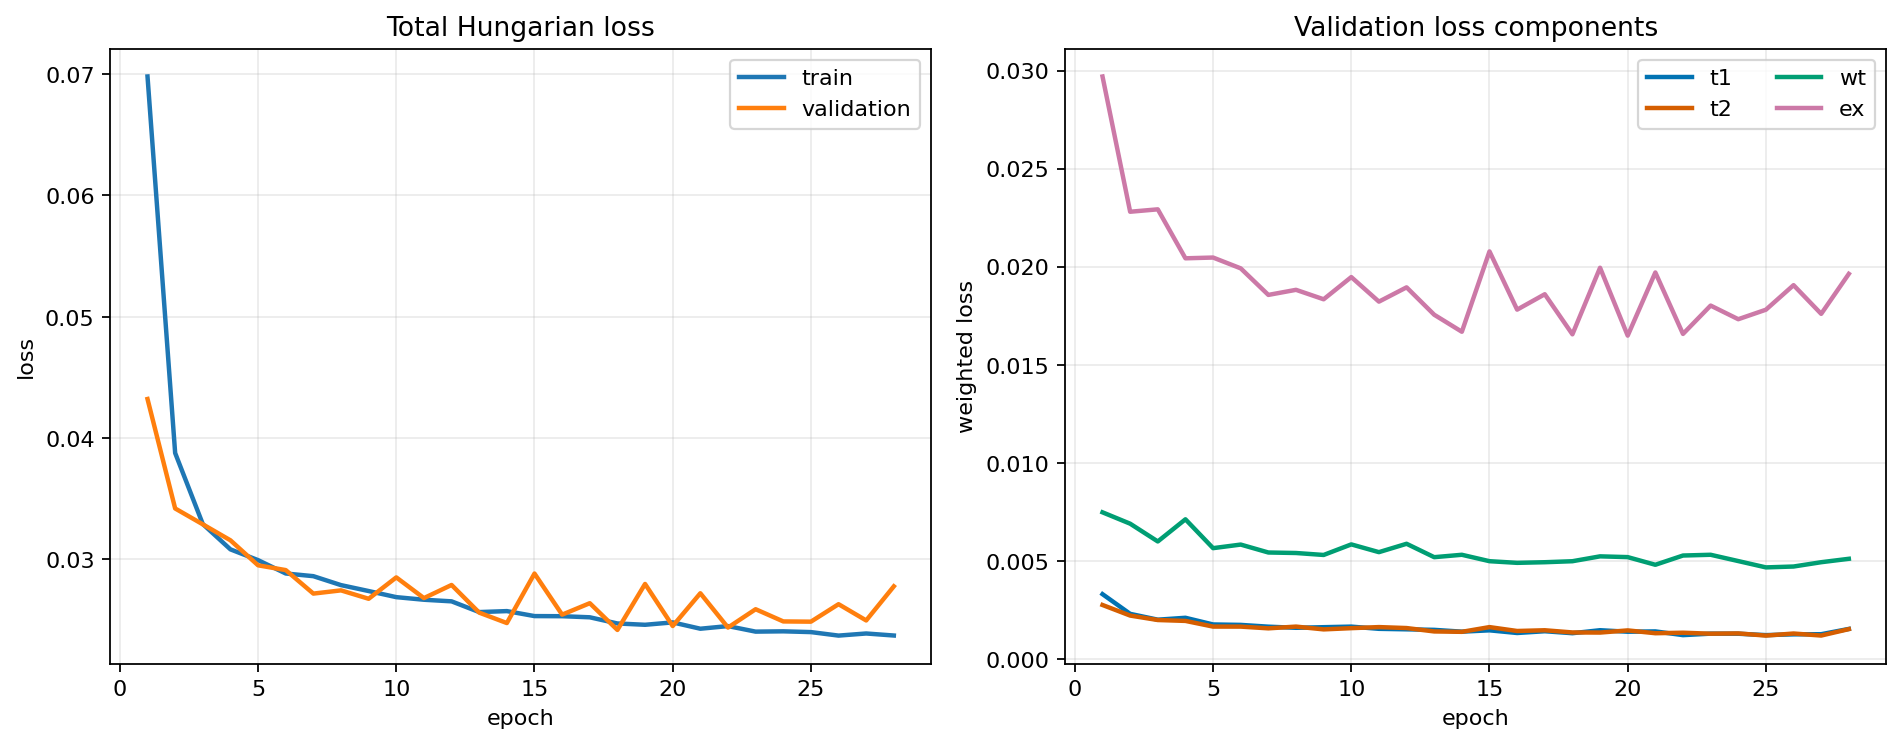

In [3]:
checkpoint_table = pd.DataFrame([
    ("Model parameters", f"{run['model_parameters']:,}"),
    ("Selected epoch", int(run["checkpoint_epoch_zero_based"]) + 1),
    ("Selected validation loss", run["checkpoint_validation_loss"]),
    ("Training seed", run["train_seed"]),
    ("Checkpoint SHA-256", run["checkpoint_sha256"]),
], columns=["Checkpoint field", "Value"])
display(checkpoint_table)
show_figure("training_curves.png")

## 4. How the existence threshold was decided

A ten-query model always emits ten parameter proposals. A proposal becomes a reported
compartment only when its existence probability exceeds a threshold.

Using 0.5 simply because it is conventional is not guaranteed to optimize compartment
counting. The threshold was therefore swept from 0.05 to 0.95 on **validation only**.

Selection order:

1. maximize exact count accuracy;
2. minimize count MAE;
3. maximize existence F1;
4. if still tied, prefer the value closest to 0.5.

The selected value, **0.79**, was then frozen before test and SNR evaluation.

,threshold,count_accuracy,count_mae,existence_precision,existence_recall,existence_f1
decision,,,,,,
default 0.50,0.50,63.91%,0.381,85.56%,97.39%,91.09%
selected 0.79,0.79,74.13%,0.270,96.04%,90.24%,93.05%


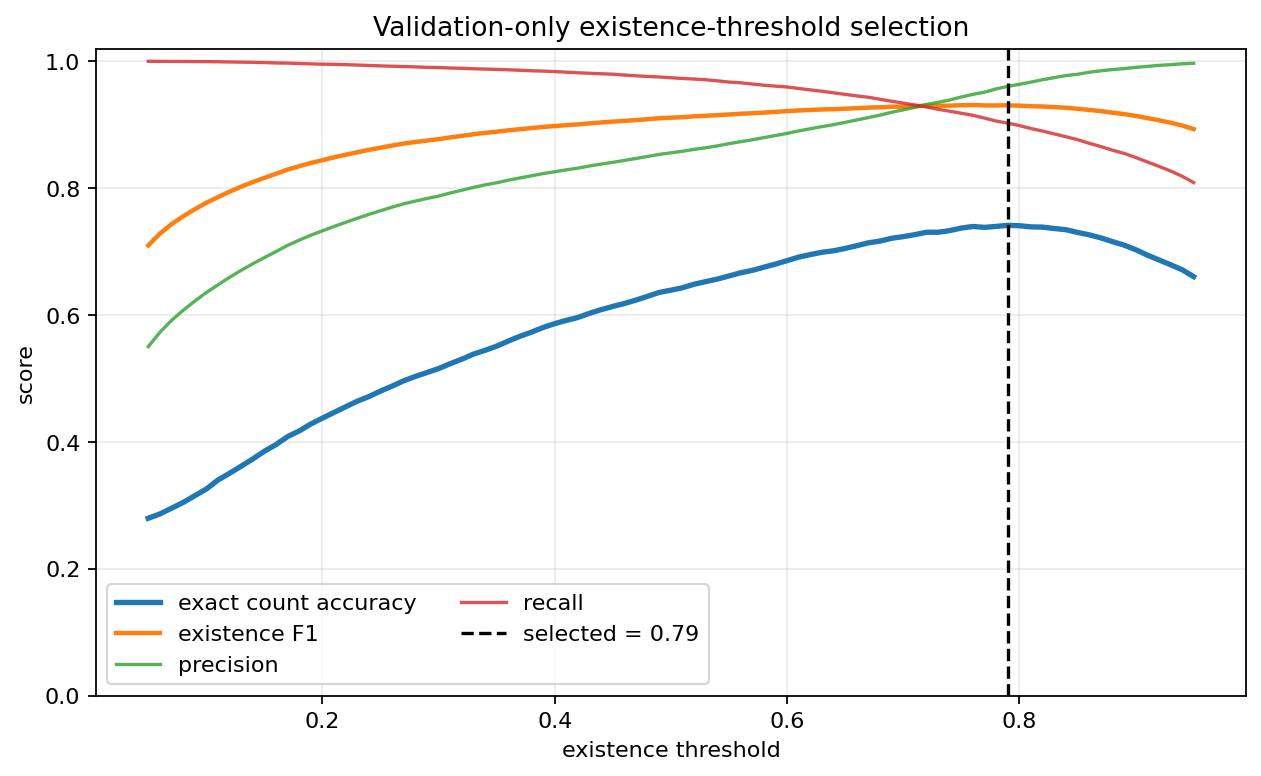

In [4]:
curve = pd.DataFrame(calibration["curve"])
selected_threshold = calibration["selected_threshold"]
compare = pd.concat([
    curve.iloc[[(curve["threshold"] - 0.50).abs().argmin()]].assign(decision="default 0.50"),
    curve.iloc[[(curve["threshold"] - selected_threshold).abs().argmin()]]
         .assign(decision=f"selected {selected_threshold:.2f}"),
])
compare = compare[
    ["decision", "threshold", "count_accuracy", "count_mae",
     "existence_precision", "existence_recall", "existence_f1"]
].set_index("decision")
display(compare.style.format({
    "threshold": "{:.2f}",
    "count_accuracy": "{:.2%}",
    "count_mae": "{:.3f}",
    "existence_precision": "{:.2%}",
    "existence_recall": "{:.2%}",
    "existence_f1": "{:.2%}",
}))
show_figure("threshold_calibration.png", width=900)

<div class="caveat"><b>Important:</b> the earlier 0.5-threshold test result already existed,
so the project cannot claim the test was historically never viewed. The finalized
procedure itself is still correct: its 0.79 choice uses validation only, and the same
frozen value is applied to test and every SNR rung.</div>

## 5. Headline held-out test result

These numbers are consequences of the already frozen model and threshold. None of them
selected the checkpoint or threshold.

In [5]:
cards = [
    ("Exact count accuracy", f"{metrics['count_accuracy']:.1%}"),
    ("Existence F1", f"{metrics['existence_f1']:.1%}"),
    ("Median relative T1", f"{metrics['t1_rel_median']:.1%}"),
    ("Median relative T2", f"{metrics['t2_rel_median']:.1%}"),
    ("Median weight error", f"{metrics['w_mae']:.1%}"),
    ("Count MAE", f"{metrics['count_mae']:.3f}"),
    ("Existence precision", f"{metrics['existence_precision']:.1%}"),
    ("Existence recall", f"{metrics['existence_recall']:.1%}"),
]
display(HTML(
    '<div class="baseline-card-grid">' +
    "".join(
        f'<div class="baseline-card"><div class="value">{value}</div>'
        f'<div class="label">{label}</div></div>'
        for label, value in cards
    ) +
    "</div>"
))

## 6. Counting performance by difficulty

Aggregate accuracy hides the actual pattern:

- one compartment is usually easy;
- two compartments can be under- or over-counted;
- three compartments are mainly under-counted as two.

The balanced test split gives each count equal influence, rather than allowing an easy
class to dominate the headline.

,voxels,exact count accuracy,count MAE,median T1 relative,median T2 relative,median weight absolute
true count,,,,,,
1,3333,96.49%,0.037,2.94%,4.44%,0.86%
2,3333,64.63%,0.354,8.63%,13.47%,5.12%
3,3333,60.91%,0.422,17.30%,26.30%,6.73%


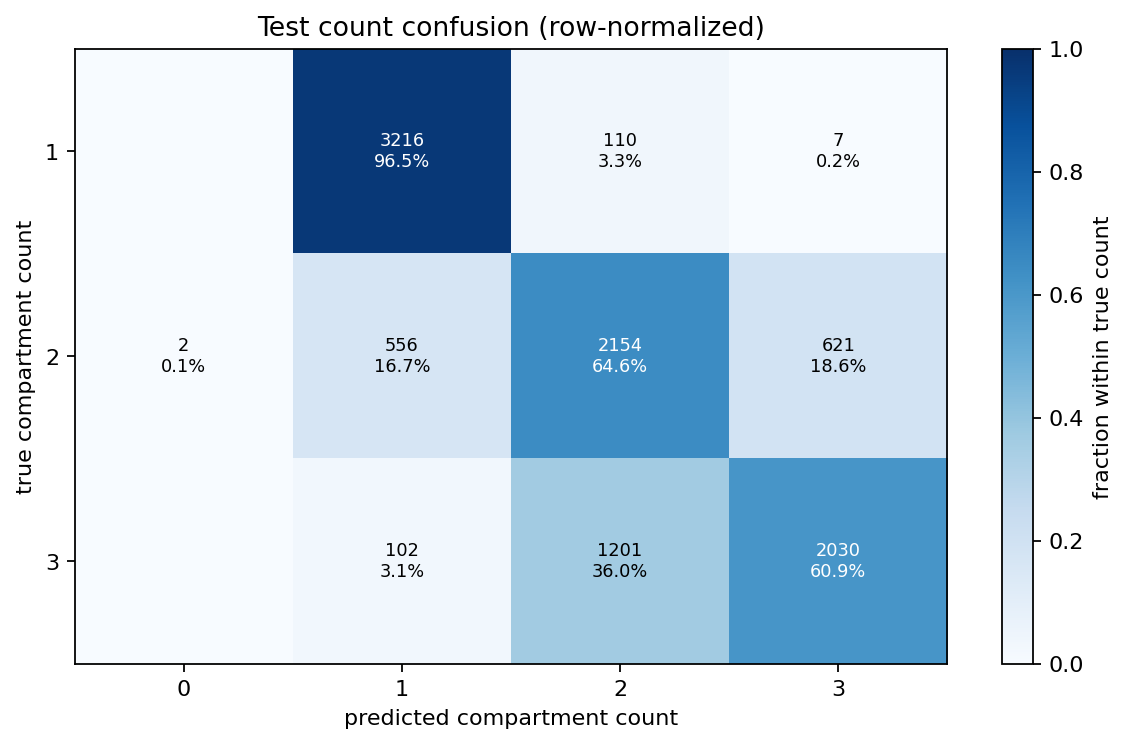

In [6]:
per_count = []
for n in (1, 2, 3):
    per_count.append({
        "true count": n,
        "voxels": metrics[f"n_voxels_n{n}"],
        "exact count accuracy": metrics[f"count_accuracy_n{n}"],
        "count MAE": metrics[f"count_mae_n{n}"],
        "median T1 relative": metrics[f"n{n}_t1_rel_median"],
        "median T2 relative": metrics[f"n{n}_t2_rel_median"],
        "median weight absolute": metrics[f"n{n}_w_mae"],
    })
per_count = pd.DataFrame(per_count).set_index("true count")
display(per_count.style.format({
    "exact count accuracy": "{:.2%}",
    "count MAE": "{:.3f}",
    "median T1 relative": "{:.2%}",
    "median T2 relative": "{:.2%}",
    "median weight absolute": "{:.2%}",
}))
show_figure("count_confusion.png", width=800)

## 7. How to read the parameter errors

T1, T2, and weight are scored after Hungarian matching in log-T1/log-T2 space. Matching is
necessary because compartments are an unordered set.

There are two related views:

- **all matched pairs:** includes whatever compartments the model found;
- **correct-count voxels:** restricts to voxels where the reported count is right.

Matched error alone can flatter an under-counting model: a missed hard component produces
no regression error. That is why count accuracy, precision/recall, and the confusion
matrix must be reported beside regression errors.

,voxels,matched compartments,median relative T1,median relative T2,median absolute weight
scope,,,,,
All voxels / matched pairs,9999,18033,9.17%,14.42%,4.44%
Correct-count voxels only,7400,13614,9.00%,14.36%,3.60%


,Metric,Value,Unit
0,Mean absolute T1,205.438011,ms
1,Mean absolute T2,63.551653,ms
2,Mean absolute weight,0.089096,fraction


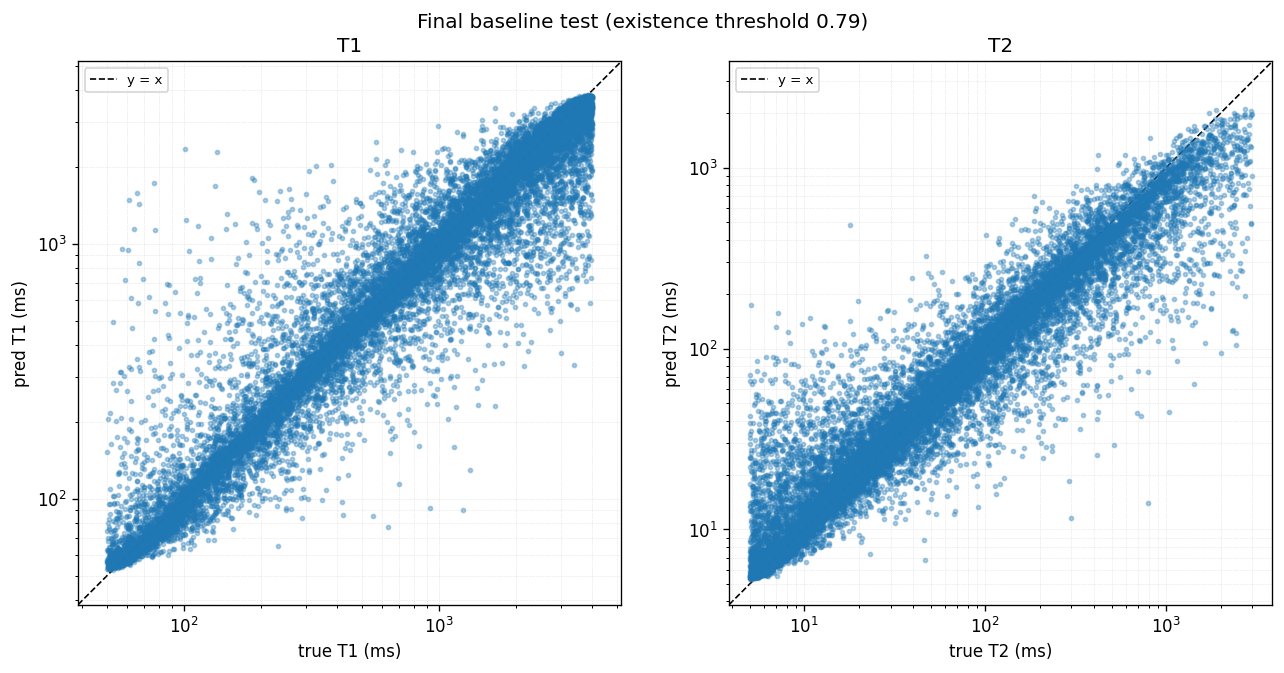

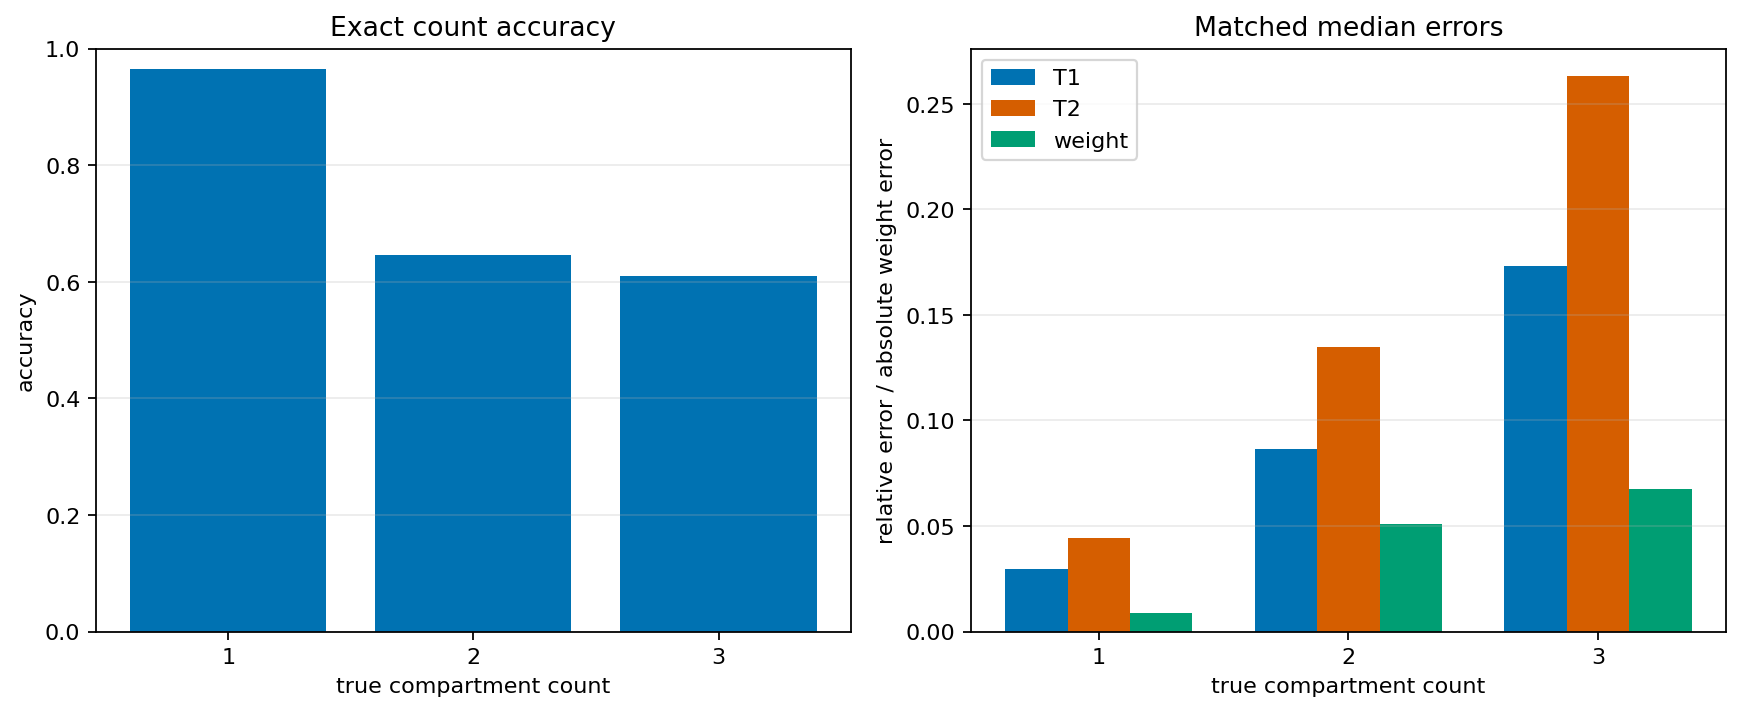

In [7]:
matching_views = pd.DataFrame([
    {
        "scope": "All voxels / matched pairs",
        "voxels": metrics["n_voxels"],
        "matched compartments": metrics["n_matched"],
        "median relative T1": metrics["t1_rel_median"],
        "median relative T2": metrics["t2_rel_median"],
        "median absolute weight": metrics["w_mae"],
    },
    {
        "scope": "Correct-count voxels only",
        "voxels": metrics["cc_n_voxels"],
        "matched compartments": metrics["cc_n_matched"],
        "median relative T1": metrics["cc_t1_rel_median"],
        "median relative T2": metrics["cc_t2_rel_median"],
        "median absolute weight": metrics["cc_w_mae"],
    },
]).set_index("scope")
display(matching_views.style.format({
    "median relative T1": "{:.2%}",
    "median relative T2": "{:.2%}",
    "median absolute weight": "{:.2%}",
}))

physical_units = pd.DataFrame([
    ("Mean absolute T1", metrics["t1_abs_mean_ms"], "ms"),
    ("Mean absolute T2", metrics["t2_abs_mean_ms"], "ms"),
    ("Mean absolute weight", metrics["w_abs_mean"], "fraction"),
], columns=["Metric", "Value", "Unit"])
display(physical_units)
show_figure("matched_t1_t2.png")
show_figure("errors_by_true_count.png")

## 8. Physical consistency and signal reconstruction

The baseline deliberately reports raw query outputs:

- no forced `T1 > T2`;
- no weight renormalization;
- no merging of nearby predictions;
- no physics-consistency training loss.

This lets us test whether physical structure was learned rather than imposed afterward.

For signal reconstruction, predicted parameters are passed through the same IR-MSE forward
model. The comparison uses the same per-voxel max normalization seen by the network.
`truth → observed` is the empirical noise floor; `prediction → observed` includes both
parameter error and measurement noise.

In [8]:
physical = pd.DataFrame([
    ("Predictions with T2 ≥ T1", metrics["t2_ge_t1_rate"], "rate"),
    ("Median |sum(weights) − 1|", metrics["weight_sum_dev_median"], "fraction"),
    ("Predicted signal vs observed", metrics["signal_rmse_prediction_vs_observed_median"], "RMSE"),
    ("True clean signal vs observed", metrics["signal_rmse_truth_vs_observed_median"], "RMSE"),
    ("Predicted signal vs true clean", metrics["signal_rmse_prediction_vs_truth_median"], "RMSE"),
], columns=["Check", "Value", "Interpretation"])
display(physical.style.format({"Value": "{:.5f}"}))

ratio = (
    metrics["signal_rmse_prediction_vs_observed_median"] /
    metrics["signal_rmse_truth_vs_observed_median"]
)
display(Markdown(
    f"The median prediction-to-observation RMSE is **{ratio:.2f}×** the true-parameter "
    "noise floor. The model reconstructs the signal reasonably, but parameter ambiguity "
    "and counting errors remain visible."
))

,Check,Value,Interpretation
0,Predictions with T2 ≥ T1,0.00447,rate
1,Median |sum(weights) − 1|,0.03420,fraction
2,Predicted signal vs observed,0.02665,RMSE
3,True clean signal vs observed,0.01198,RMSE
4,Predicted signal vs true clean,0.02192,RMSE


The median prediction-to-observation RMSE is **2.22×** the true-parameter noise floor. The model reconstructs the signal reasonably, but parameter ambiguity and counting errors remain visible.

## 9. How noise robustness was decided

Every SNR rung uses:

- the same underlying voxel parameters;
- the same standardized Gaussian-noise realization;
- only a different noise amplitude;
- the same checkpoint and frozen 0.79 threshold.

This paired construction isolates SNR instead of comparing unrelated samples. SNR 20 is
marked **extrapolation** because training starts at SNR 30.

,regime,count accuracy,existence F1,median T1 relative,median T2 relative,median weight absolute,signal RMSE
SNR,,,,,,,
20.000000,extrapolation,61.97%,89.53%,13.11%,19.65%,6.09%,0.0598
40.000000,training range,70.69%,92.10%,9.86%,15.62%,4.73%,0.0351
60.000000,training range,73.01%,92.74%,9.27%,14.39%,4.44%,0.0280
100.000000,training range,74.43%,93.13%,8.66%,13.83%,4.25%,0.0236
150.000000,training range,74.77%,93.24%,8.50%,13.67%,4.21%,0.0220


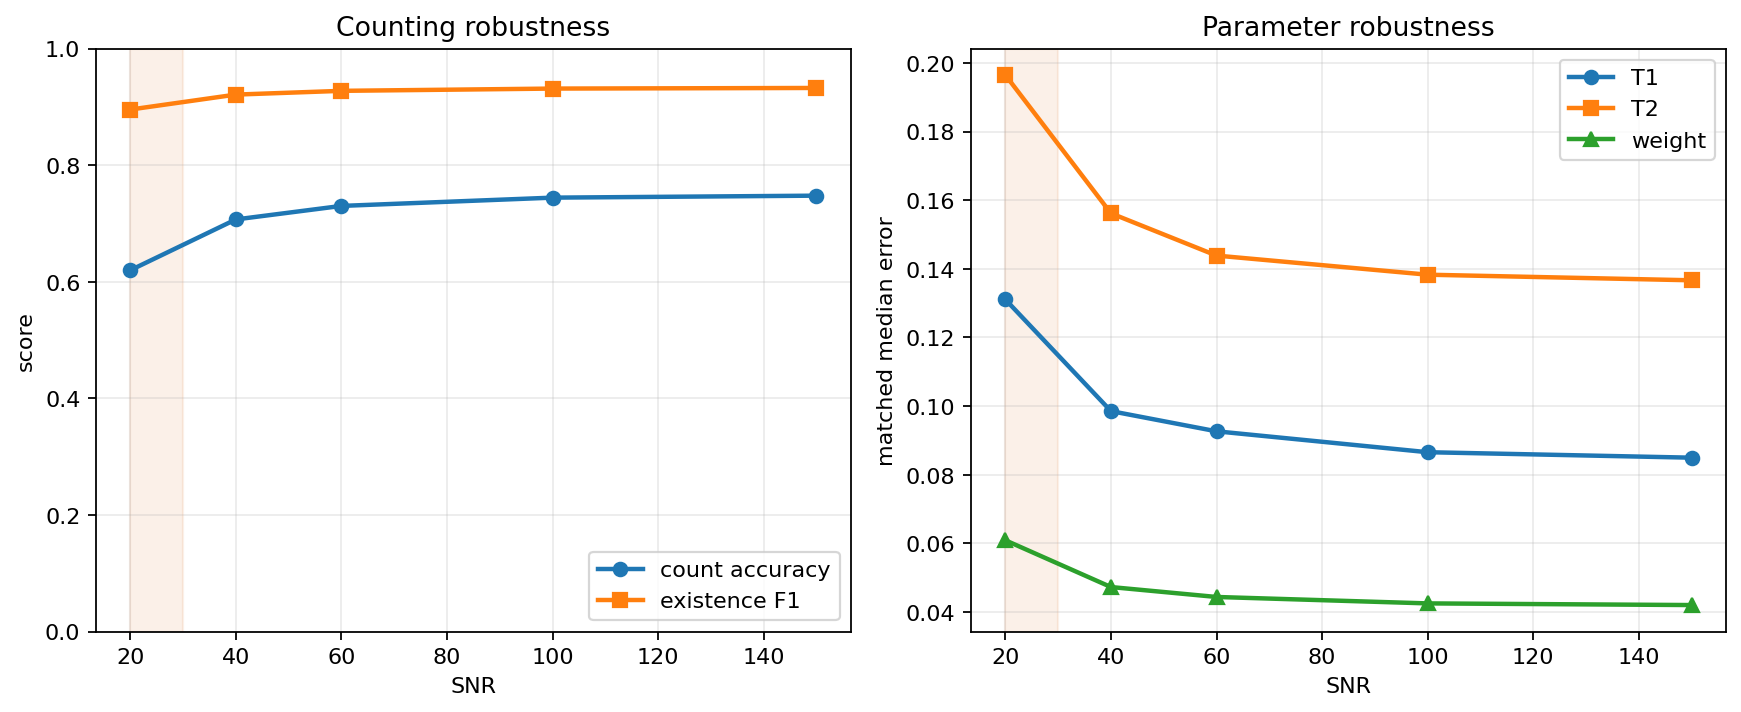

In [9]:
snr_rows = []
for record in sorted(ladder.values(), key=lambda r: r["snr"]):
    snr_rows.append({
        "SNR": record["snr"],
        "regime": "extrapolation" if record["extrapolation"] else "training range",
        "count accuracy": record["count_accuracy"],
        "existence F1": record["existence_f1"],
        "median T1 relative": record["t1_rel_median"],
        "median T2 relative": record["t2_rel_median"],
        "median weight absolute": record["w_mae"],
        "signal RMSE": record["signal_rmse_prediction_vs_observed_median"],
    })
snr_table = pd.DataFrame(snr_rows).set_index("SNR")
display(snr_table.style.format({
    "count accuracy": "{:.2%}",
    "existence F1": "{:.2%}",
    "median T1 relative": "{:.2%}",
    "median T2 relative": "{:.2%}",
    "median weight absolute": "{:.2%}",
    "signal RMSE": "{:.4f}",
}))
show_figure("snr_robustness.png")

## 10. What is each query responsible for?

DETR queries are learned set slots, not predefined tissue labels. We therefore do **not**
name Q2 “CSF” or Q3 “myelin.” Query responsibility is measured empirically:

1. apply the frozen existence threshold;
2. Hungarian-match active predictions to true compartments;
3. record activity by true count and the matched true T1/T2 distribution.

Stable, narrow distributions would indicate specialization. Overlapping distributions mean
query identities remain partly interchangeable.

,active rate,matched / active,active at n=1,active at n=2,active at n=3,matched median T1 (ms),matched median T2 (ms),matched median weight
query,,,,,,,,
Q0,0.00%,—,0.00%,0.00%,0.00%,—,—,—
Q1,0.00%,—,0.00%,0.00%,0.00%,—,—,—
Q2,57.47%,98.22%,2.73%,76.09%,93.58%,1543,192,0.38
Q3,57.89%,98.76%,0.99%,77.68%,94.99%,297,20,0.46
Q4,41.19%,99.85%,98.86%,20.52%,4.20%,709,46,1.00
Q5,0.00%,—,0.00%,0.00%,0.00%,—,—,—
Q6,0.00%,—,0.00%,0.00%,0.00%,—,—,—
Q7,30.92%,81.73%,1.11%,26.79%,64.87%,558,40,0.25
Q8,0.33%,100.00%,0.03%,0.75%,0.21%,1129,28,0.80


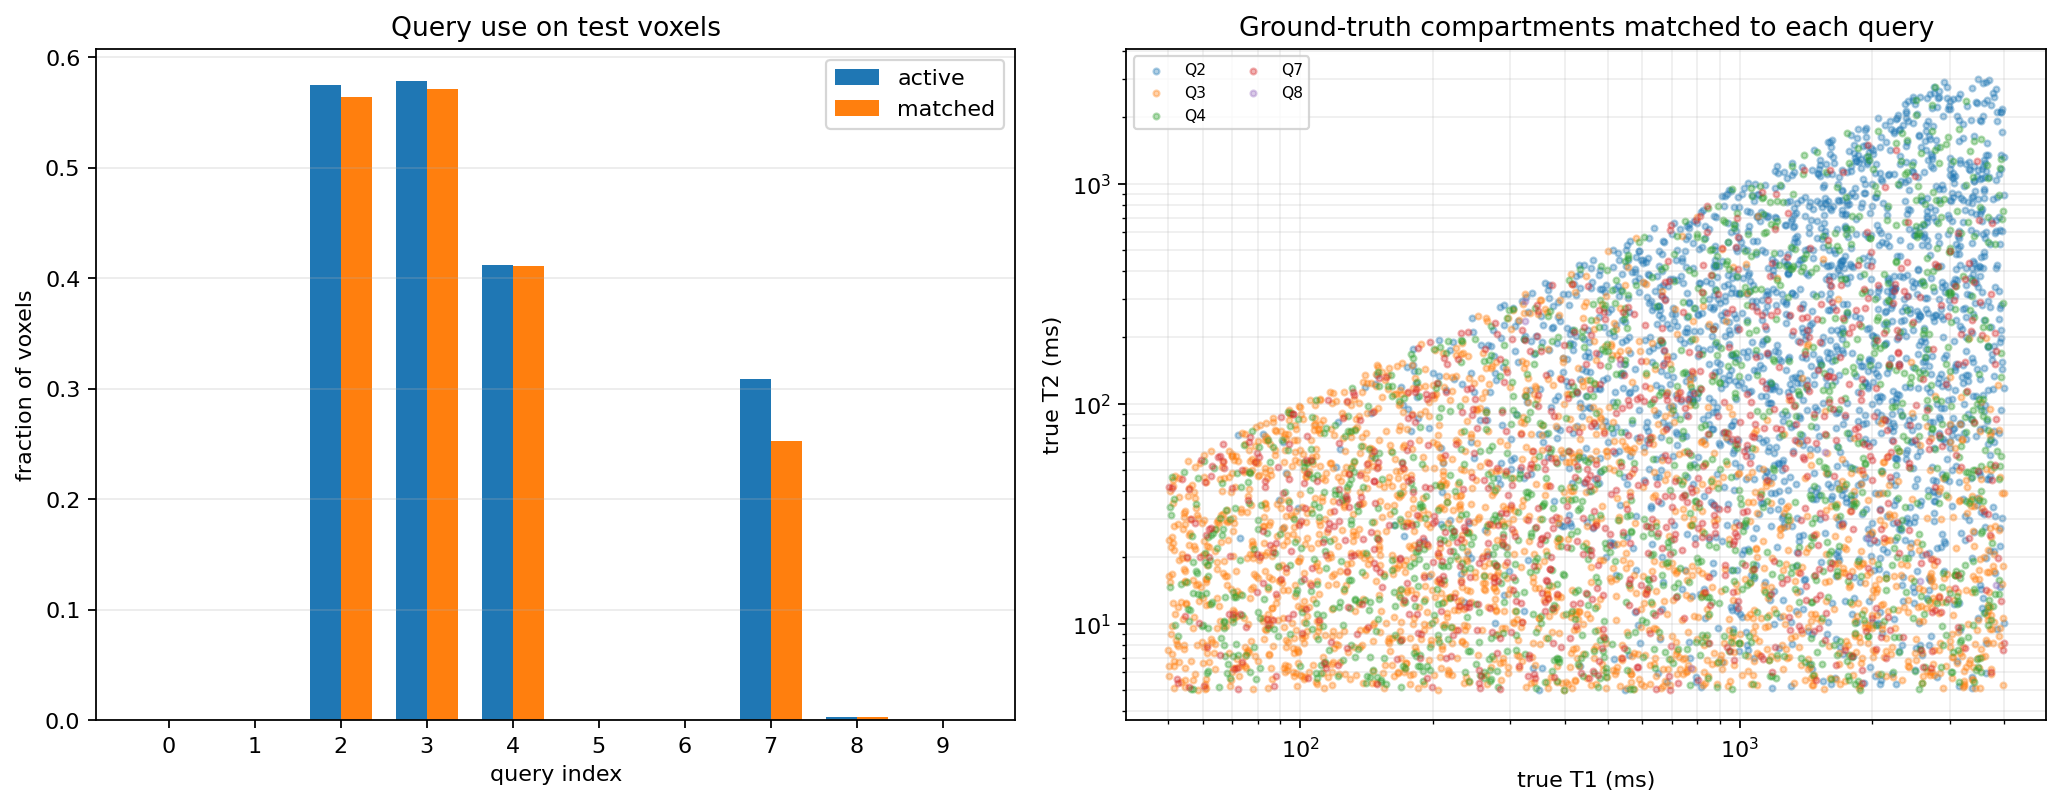

In [10]:
query_rows = []
for q in queries["queries"]:
    by_count = q["active_rate_by_true_count"]
    query_rows.append({
        "query": f"Q{q['query']}",
        "active rate": q["active_rate"],
        "matched / active": q["matched_fraction_of_active"],
        "active at n=1": by_count["1"],
        "active at n=2": by_count["2"],
        "active at n=3": by_count["3"],
        "matched median T1 (ms)": q["matched_true_t1_median_ms"],
        "matched median T2 (ms)": q["matched_true_t2_median_ms"],
        "matched median weight": q["matched_true_w_median"],
    })
query_table = pd.DataFrame(query_rows).set_index("query")
display(query_table.style.format({
    "active rate": "{:.2%}",
    "matched / active": "{:.2%}",
    "active at n=1": "{:.2%}",
    "active at n=2": "{:.2%}",
    "active at n=3": "{:.2%}",
    "matched median T1 (ms)": "{:.0f}",
    "matched median T2 (ms)": "{:.0f}",
    "matched median weight": "{:.2f}",
}, na_rep="—"))
show_figure("query_specialization.png")

**Interpretation**

- Q4 handles almost every one-compartment voxel.
- Q2 tends toward longer T1/T2 components.
- Q3 tends toward shorter T1/T2 components.
- Q7 is mainly a multi-component slot.
- Q0, Q1, Q5, Q6, and Q9 are inactive; Q8 is nearly inactive.

The distributions still overlap, so this is partial specialization—not a fixed biological
identity. The inactivity result is the evidence for running a 5/10/15/20 query-count
ablation next.

## 11. How successes and failures were selected

Examples were chosen deterministically, not by hand:

- one success per true count: correct count with the smallest median matched log-parameter
  error;
- one failure per true count: prefer a wrong count, then the largest count difference and
  parameter error.

This prevents cherry-picking only flattering examples.

,kind,test index,true count,predicted count,active queries,selection error score
0,success,305,1,1,Q4,0.002933
1,success,4086,2,2,"Q3, Q7",0.040241
2,success,7116,3,3,"Q2, Q3, Q7",0.049828
3,failure,2777,1,3,"Q2, Q3, Q7",0.599611
4,failure,4146,2,0,none,NaN
5,failure,8979,3,1,Q7,1.944671


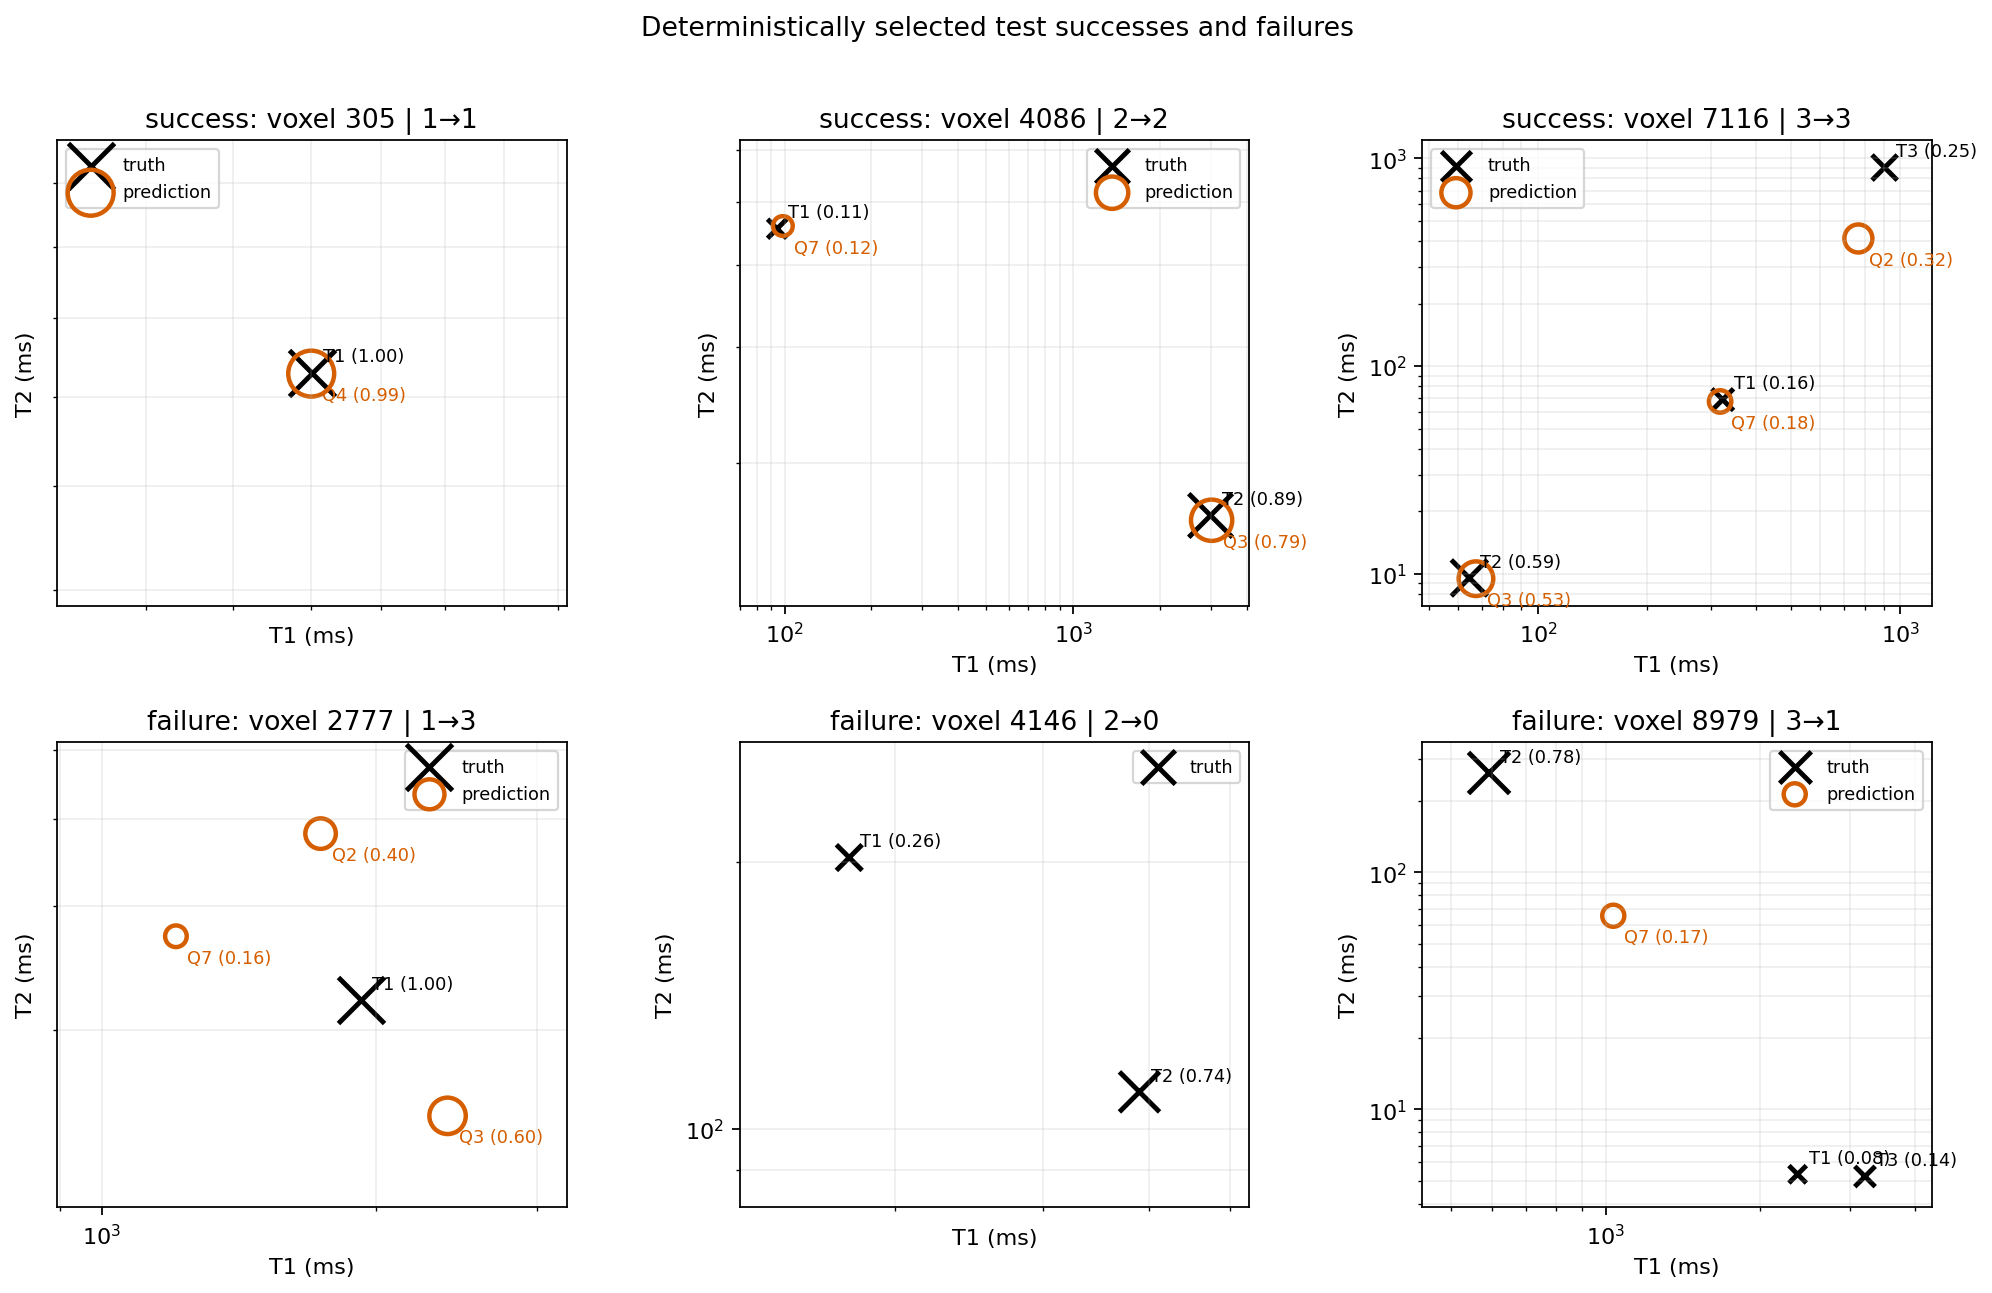

In [11]:
example_rows = []
for kind in ("successes", "failures"):
    for item in examples[kind]:
        example_rows.append({
            "kind": {"successes": "success", "failures": "failure"}[kind],
            "test index": item["index"],
            "true count": item["true_count"],
            "predicted count": item["pred_count"],
            "active queries": ", ".join(f"Q{q}" for q in item["queries"]) or "none",
            "selection error score": item["error_score"],
        })
display(pd.DataFrame(example_rows))
show_figure("success_failure_examples.png")

## 12. Final decision

### What the baseline establishes

- The diffusion-DETR idea ports successfully to signed T1–T2 correlation signals.
- Training is stable and reproducible.
- The model produces mostly physical outputs without hard constraints.
- One-compartment recovery is strong.
- Multi-compartment counting and parameter recovery work, but remain the main limitation.
- Noise causes smooth degradation rather than collapse.

### What it does not establish

- real-data generalization;
- biological tissue labels for individual queries;
- whether ten queries are optimal;
- whether loss weights are optimal;
- whether signal-consistency training improves parameter identifiability.

### Why the next order is justified

1. **Query-count ablation (5/10/15/20):** immediately motivated by five inactive queries.
2. **Limited Optuna study:** validation-only selection of loss balance and optimizer
   hyperparameters, with the test split sealed until the study is finished.
3. **Physics-consistency loss:** a clean baseline-vs-physics ablation using the existing
   differentiable IR-MSE forward model.

The finalized baseline is therefore the reference point, not the end of the research
program.

In [12]:
decision_summary = pd.DataFrame([
    ("Baseline status", summary["status"], "Synthetic proof of concept is complete"),
    ("Frozen threshold", f"{summary['selected_existence_threshold']:.2f}",
     "Selected on validation only"),
    ("Held-out count accuracy", f"{metrics['count_accuracy']:.2%}",
     "Report, not a selection criterion"),
    ("Main failure mode", "n=3 → n=2",
     "36.0% of true three-compartment voxels"),
    ("First next experiment", "query-count ablation",
     "Five queries are inactive at the frozen threshold"),
], columns=["Decision", "Outcome", "Reason"])
display(decision_summary)

,Decision,Outcome,Reason
0,Baseline status,complete,Synthetic proof of concept is complete
1,Frozen threshold,0.79,Selected on validation only
2,Held-out count accuracy,74.01%,"Report, not a selection criterion"
3,Main failure mode,n=3 → n=2,36.0% of true three-compartment voxels
4,First next experiment,query-count ablation,Five queries are inactive at the frozen threshold
